In [2]:

from collections import Counter
import pandas as pd
import os
import sys
import datetime 
import numpy as np
### funciones processing
##import utils.discovery_functions as disc
from datetime import datetime
import time
###import ppscore as pps
from sklearn.ensemble import RandomForestClassifier
###from category_encoders import target_encoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

ModuleNotFoundError: No module named 'pandas'

In [4]:
!pip3 install pandas

"pip3" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [1]:
df = pd.read_csv('resp_TN_infopyp_datoslaboral_test.txt')
df.to_csv('data.csv', index=None)
del df

NameError: name 'pd' is not defined

In [5]:
df = pd.read_csv('data.csv')


In [6]:
df.head()

,target,tipdoc,key_value,marca_tipo,mtolineatotal_val,nombre_tc,marca,caidas_reactivas,segmento,subsegmento,...,trx_app_config,trx_app_consultas,trx_app_gestion,trx_app_misfinanzas,trx_app_pagos,trx_app_adqui,trx_app_recarga,trx_app_transf,trx_clubsueldo,codmes
0,0,1,36D0DC487D5F11DADAE01FAD1FF2D256A5E3DE9AC54BAC...,206,53550.0,AMEX CEN THE PLATINUM CARD,AMEX,NaN,1BC,SV,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,202301
1,0,1,E2B7732F681D846CD47C68F8345AAFC221B41AE97F8DF9...,123,35000.0,VISA PLATINUM,VISA,NaN,4,SV,...,0.0,55.0,0.0,0.0,6.0,0.0,0.0,13.0,0.0,202302
2,0,1,1C9014DB2A723627EA5C46188228FC04A4FDA466955C4F...,123,26400.0,VISA PLATINUM,VISA,NaN,2,SV,...,0.0,100.0,0.0,0.0,5.0,0.0,1.0,7.0,0.0,202303
3,0,1,F202BFF65D4C4C0DFE04925A2A7CAA923BA62E3119EA8C...,206,31700.0,AMEX CEN THE PLATINUM CARD,AMEX,NaN,2,SV,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,202311
4,0,1,CEB6CCF11E609A82ADF2C2FC3EE8FD040381BB5C3A5A52...,101,23300.0,VISA CLASICA INTERNACIONAL,VISA,NaN,2,SV,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,14.0,0.0,202307


In [7]:
df.codmes.value_counts()

codmes
202311    118192
202302    110740
202301    107324
202304    102598
202306     95904
202309     94252
202310     89062
202308     76292
202303     72751
202307     67261
202305     65624
Name: count, dtype: int64

In [8]:
df.target.value_counts()

target
0    975466
1     24534
Name: count, dtype: int64

In [9]:
df.shape

(1000000, 196)

In [10]:
str_vars = df.dtypes.index[(df.dtypes == object)]
for var in str_vars:
   print()
   print("***** ",var," ********")
   print("Cantidad de categorias distintas", len(df[var].unique()))
   print("Cantiddad de nulls",sum(df[var].isnull()) )
   print(df[var].value_counts().head())


*****  key_value  ********
Cantidad de categorias distintas 482681
Cantiddad de nulls 0
key_value
218E29FD60D5B4A90BAFB891E50F6D7A4A42CCE1EDE865F5C5A89F944F67AE0A    13
FF24F8A4DCA24AD6914EC00AA6DC9031AF857EEE6094F56A6F8B6BD420BDBB93    12
27FA00AB1D607F007554FD2A2D7FDF8011737BD014B8DE9B94659C8DA1F10DEB    12
6CFBF7F9019A1AC4CEF8C25128C0677523F6EDB360841B0E3ED2D61AE3AC0EAD    12
490716B155D43ECF928AF041DE39FAFD76E33B7F68936FA90BEAE1D515268BC0    11
Name: count, dtype: int64

*****  nombre_tc  ********
Cantidad de categorias distintas 10
Cantiddad de nulls 0
nombre_tc
VISA CLASICA INTERNACIONAL    225404
VISA PLATINUM                 164728
VISA SIGNATURE                133873
VISA INFINITE                 101951
AMEX CEN THE PLATINUM CARD     76317
Name: count, dtype: int64

*****  marca  ********
Cantidad de categorias distintas 2
Cantiddad de nulls 0
marca
VISA    625956
AMEX    374044
Name: count, dtype: int64

*****  segmento  ********
Cantidad de categorias distintas 7
Cantiddad 

In [11]:
df_1=df

In [12]:
df_1.nombre_tc.value_counts()

nombre_tc
VISA CLASICA INTERNACIONAL    225404
VISA PLATINUM                 164728
VISA SIGNATURE                133873
VISA INFINITE                 101951
AMEX CEN THE PLATINUM CARD     76317
AMEX BB PLATINUM               67317
AMEX CEN GOLD                  63280
AMEX CEN GREEN                 60228
AMEX BB BLACK                  55415
AMEX BLUE                      51487
Name: count, dtype: int64

In [13]:
df_1['nombre_tc'] = df_1['nombre_tc'].map({
    'VISA CLASICA INTERNACIONAL':1,
    'VISA PLATINUM':2,
    'VISA SIGNATURE':3,
    'VISA INFINITE':4,
    'AMEX CEN THE PLATINUM CARD':5,
     'AMEX BB PLATINUM':6,
     'AMEX CEN GOLD ':7,
     'AMEX CEN GREEN':8,
     'AMEX BLUE':9
    }).fillna(-1)

In [14]:
df_1['marca'] = df_1['marca'].map({'VISA':1, 'AMEX':0}).fillna(-1)

In [15]:
df_1.segmento.value_counts()

segmento
2      403493
3      261493
1A     181403
1BC    102956
4       35607
6        9929
Name: count, dtype: int64

In [16]:
df_1['segmento'] = df_1['segmento'].map({
    '2':1,
    '3':2,
    '1A':3,
    '1BC':4,
    '4':5,
    '6':6
    }).fillna(-1)

In [17]:
df_1.subsegmento.value_counts()

subsegmento
SV    733388
3D    109612
3C     86202
3E     52644
3B     11563
3A      1472
Name: count, dtype: int64

In [18]:
df_1['subsegmento'] = df_1['subsegmento'].map({
    'SV':1,
    '3D':2,
    '3C':3,
    '3E':4,
    '3B':5,
    '3A':6
    }).fillna(-1)

In [19]:
df_1.grupo_final.value_counts()

grupo_final
Digital              618516
Light user           115191
Tradicional          103206
Sin transacciones     25431
Agente                 9813
ATM                    4944
Name: count, dtype: int64

In [20]:
df_1['grupo_final'] = df_1['grupo_final'].map({
    'Digital':1,
    'Light user':2,
    'Tradicional':3,
    'Sin transacciones':4,
    'Agente':5
    }).fillna(-1)

In [21]:
dummy_variables = [ 'flg_cliente_adel_sueldo',
    'flg_cliente_convenio', 'flg_cliente_hipotecario',
    'flg_cliente_libre_dispon', 'flg_cliente_cred_pref',
    'flg_cliente_pre_facil', 'flg_cliente_tc', 'flg_cliente_2da_tc',
    'flg_parque_tc', 'flg_act_sal_tc', 'flg_cliente_extracash_tc',
    'flg_cliente_vehicular', 'flg_cliente_ahor_cred', 'flg_cliente_cts',
    'flg_cliente_inversion', 'flg_cliente_millonaria',
    'flg_cliente_alcancia', 'flg_cliente_planilla',
    'flg_cliente_planilla_act_sal', 'flg_cliente_planilla_abon',
    'flg_cliente_planilla_depo', 'flg_cliente_plazo_fijo',
    'flg_cliente_txs', 'flg_cliente_seguro', 'flg_cliente_domiciliacion',
    'flg_colaborador', 'flg_castigado', 'flg_foco', 'flg_gestionable',
    'flg_consumo_tc', 'flg_castigado_sf','flg_principalidad']

In [22]:
dummy_variables = [element for element in dummy_variables if element in list(df_1)]
print(len(dummy_variables))
dummy_variables

32


['flg_cliente_adel_sueldo',
 'flg_cliente_convenio',
 'flg_cliente_hipotecario',
 'flg_cliente_libre_dispon',
 'flg_cliente_cred_pref',
 'flg_cliente_pre_facil',
 'flg_cliente_tc',
 'flg_cliente_2da_tc',
 'flg_parque_tc',
 'flg_act_sal_tc',
 'flg_cliente_extracash_tc',
 'flg_cliente_vehicular',
 'flg_cliente_ahor_cred',
 'flg_cliente_cts',
 'flg_cliente_inversion',
 'flg_cliente_millonaria',
 'flg_cliente_alcancia',
 'flg_cliente_planilla',
 'flg_cliente_planilla_act_sal',
 'flg_cliente_planilla_abon',
 'flg_cliente_planilla_depo',
 'flg_cliente_plazo_fijo',
 'flg_cliente_txs',
 'flg_cliente_seguro',
 'flg_cliente_domiciliacion',
 'flg_colaborador',
 'flg_castigado',
 'flg_foco',
 'flg_gestionable',
 'flg_consumo_tc',
 'flg_castigado_sf',
 'flg_principalidad']

In [23]:
import re
for column in dummy_variables:
    df_1[column] = df_1[column].map(lambda value: value if isinstance(value, str) == False else np.nan if value.strip()=='?' else re.sub('\W', '_', value.strip()).lower())

In [24]:
df_1 = pd.get_dummies(df_1, columns=dummy_variables)

In [25]:
str_vars = df_1.dtypes.index[(df_1.dtypes == object)]

In [26]:
df_2 = df_1.fillna(0)

In [27]:
to_drop =  [ 'key_value']
df_3 = df_2.drop(to_drop,axis=1)

In [28]:
str_vars = df_3.dtypes.index[(df_3.dtypes == object)]
for var in str_vars:
   print()
   print("***** ",var," ********")
   print("Cantidad de categorias distintas", len(df_3[var].unique()))
   print("Cantiddad de nulls",sum(df_3[var].isnull()) )
   print(df_3[var].value_counts().head())

In [29]:
df_numerical_corr = df_3.corr()['target']
df_numerical_most_corr = df_numerical_corr[abs(df_numerical_corr) > 0.0001].sort_values(ascending=False)
df_numerical_most_corr.head(100)

target                     1.000000
flg_parque_tc_n            0.202382
rec_campadqtcr06m          0.191423
rec_campadqtcrtlv06m       0.178870
flg_act_sal_tc_n           0.163701
                             ...   
flg_cliente_ahor_cred_s    0.000910
rec_camptot06m             0.000535
bpi_trx_con_prom           0.000475
bpi_trx_con                0.000475
trx_bpi_pagos              0.000454
Name: target, Length: 100, dtype: float64

In [30]:
df_numerical_most_corr.head(25)

target                  1.000000
flg_parque_tc_n         0.202382
rec_campadqtcr06m       0.191423
rec_campadqtcrtlv06m    0.178870
flg_act_sal_tc_n        0.163701
flg_cliente_tc_n        0.163196
frc_campadqtcr06m       0.138226
min_campadqtcr06m       0.134623
max_campadqtcr06m       0.124291
frc_campadqtcrtlv06m    0.124144
trx_bpi_config          0.036586
flg_gestionable_n       0.031836
bpi_trx_nmon_prom2      0.028130
sms_clicked_m1          0.027158
bpi_trx_prom2           0.026341
trx_halcon_otros        0.025806
trx_app_consultas       0.025703
bpi_trx_nmon_prom       0.025559
bpi_trx_nmon            0.025559
bpi_trx_nmon_max        0.024391
bpi_trx                 0.023920
bpi_trx_prom            0.023920
trx_app_config          0.023140
trx_app_misfinanzas     0.022355
bpi_trx_max             0.021217
Name: target, dtype: float64

In [31]:
variables_to_ignore = ['codmes']
variables_study = [element for element in list(df_3) if element not in variables_to_ignore]

correlation_matrix = df_3[variables_study].corr(method='pearson')

In [32]:
num_variables = len(correlation_matrix)
correlation_value = 0.75
correlated_variables = []

for row in range(1,num_variables):
    for col in range(0,row):
        if abs(correlation_matrix.iloc[row,col]) >= correlation_value:
            print('La variable {0} esta correlacionada con la variable {1} con un factor de {2}'.format(list(correlation_matrix)[row], list(correlation_matrix)[col], correlation_matrix.iloc[row,col]))
            correlated_variables.append([list(correlation_matrix)[row], list(correlation_matrix)[col], correlation_matrix.iloc[row,col]])

La variable marca esta correlacionada con la variable marca_tipo con un factor de -0.9813616492924959
La variable saldo_prom_tot_activo esta correlacionada con la variable saldo_fdp_tot_activo con un factor de 0.9914122140584317
La variable saldo_prom_tot_pasivo esta correlacionada con la variable saldo_fdp_tot_pasivo con un factor de 0.9905179761003676
La variable tenencia esta correlacionada con la variable productos con un factor de 0.8005976752376636
La variable rango_edad esta correlacionada con la variable edad con un factor de 0.9271329346840912
La variable saldo_fdp_vig_activo esta correlacionada con la variable saldo_fdp_tot_activo con un factor de 0.999477503541614
La variable saldo_fdp_vig_activo esta correlacionada con la variable saldo_prom_tot_activo con un factor de 0.990871477849778
La variable saldo_prom_vig_activo esta correlacionada con la variable saldo_fdp_tot_activo con un factor de 0.9910456555567407
La variable saldo_prom_vig_activo esta correlacionada con la va

In [33]:
columns_to_delete_correlation_target = []
for element in correlated_variables:
   if element[0] not in list(df_3) or element[1] not in list(df_3):
       break
   else:
       first = df_3.target.corr(df_3[element[0]], method='pearson')
       second = df_3.target.corr(df_3[element[1]], method='pearson')
       if abs(first) > abs(second):
           print('La variable {0} esta mas correlacionada con la variable objetiva "clase_binaria"'.format(element[0]))
           columns_to_delete_correlation_target.append(element[1])
       else: 
           print('La variable {0} esta mas correlacionada con la variable objetiva "clase_binaria"'.format(element[1]))
           columns_to_delete_correlation_target.append(element[0])

columns_to_delete_correlation_target = list(set(columns_to_delete_correlation_target))
df_3.drop(columns_to_delete_correlation_target, axis=1, inplace=True)

La variable marca_tipo esta mas correlacionada con la variable objetiva "clase_binaria"
La variable saldo_prom_tot_activo esta mas correlacionada con la variable objetiva "clase_binaria"
La variable saldo_fdp_tot_pasivo esta mas correlacionada con la variable objetiva "clase_binaria"
La variable tenencia esta mas correlacionada con la variable objetiva "clase_binaria"
La variable rango_edad esta mas correlacionada con la variable objetiva "clase_binaria"
La variable saldo_fdp_tot_activo esta mas correlacionada con la variable objetiva "clase_binaria"
La variable saldo_prom_tot_activo esta mas correlacionada con la variable objetiva "clase_binaria"
La variable saldo_prom_vig_activo esta mas correlacionada con la variable objetiva "clase_binaria"
La variable saldo_prom_tot_activo esta mas correlacionada con la variable objetiva "clase_binaria"
La variable saldo_prom_vig_activo esta mas correlacionada con la variable objetiva "clase_binaria"
La variable saldo_fdp_vig_adel_sueldo esta mas 

In [34]:
import random
number_seeds = 10

seed_value = 4
feature_importance_cumulative_value = 0.99999

random.seed(seed_value)
random_seeds = []

while len(random_seeds) < number_seeds:
   random_seeds.append(random.randint(1,1000))
   random_seeds = list(set(random_seeds))

total_feature_seeds = []
for random_seed in random_seeds:
   target = 'target'
   not_input = ['target','codmes', 'codmes_lag1','p_codmes']
   input_features = [column for column in list(df_3) if column not in not_input]

   feature_selection = RandomForestClassifier(random_state = random_seed, n_jobs=-1)
   feature_selection.fit(df_3[input_features], df_3[target])
   # display the relative importance of each attribute
   print(feature_selection.feature_importances_)
   
   feature_importance_data = sorted([[feature, importance] for feature, importance in zip(input_features, feature_selection.feature_importances_)],
   key=lambda value: value[-1], reverse=True)
   
   total_sum = 0
   elements_below_threshold = []
   for element in feature_importance_data:
       total_sum += element[1]
       if total_sum <= feature_importance_cumulative_value:
           elements_below_threshold.append(element)
       else: break
   total_feature_seeds.append(elements_below_threshold)

[0.00000000e+00 1.46658245e-02 3.17622378e-02 1.47184878e-02
 0.00000000e+00 1.00053869e-02 8.56841671e-03 3.35755270e-02
 2.86319165e-02 2.99728009e-02 1.12581125e-02 9.64799716e-03
 9.93178911e-03 0.00000000e+00 1.59356181e-03 3.89736105e-03
 3.99118163e-04 2.00340808e-02 2.50715466e-02 3.95102297e-03
 2.82335668e-02 2.95354391e-02 1.61600480e-02 3.27076258e-02
 8.62002091e-03 1.77890002e-03 2.94435154e-02 2.77560169e-02
 3.62087407e-02 7.47756504e-03 5.74699541e-03 2.87939558e-03
 2.21940315e-03 9.57924743e-03 2.06148078e-02 1.06234758e-02
 2.43520427e-02 5.09148258e-03 1.10517351e-02 5.11789442e-03
 6.50261049e-04 2.66542888e-03 1.14437312e-02 8.77860465e-03
 1.13815418e-02 2.06540494e-02 2.67082866e-02 1.13773100e-02
 2.03808423e-02 4.53222943e-03 2.73982575e-03 5.81868300e-03
 9.35651014e-03 2.13585625e-02 2.82535294e-02 2.14646373e-02
 1.27964673e-02 0.00000000e+00 2.43858240e-02 5.93755602e-03
 8.83946621e-03 2.54337784e-03 6.18885263e-04 1.58056734e-04
 4.37744442e-03 1.427731

In [35]:
selected_features = [element[0] for element in Counter([item[0] for element in total_feature_seeds for item in element]).items() if element[1] ==number_seeds]

features_dictionary = {}
for element in selected_features:
   features_dictionary[element] = []
   for results in total_feature_seeds:
       for item in results:
           if element == item[0]:
               features_dictionary[element].append(item[1])
   
   

feature_importance_data = []
for key, value in features_dictionary.items():
   feature_importance_data.append([key, np.mean(value)])
   
feature_importance_df = pd.DataFrame(data=feature_importance_data, columns=['feature', 'importance'])
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df

,feature,importance
0,prom_lin_tc_rccsf_06m,0.036992
1,ingreso_bruto,0.033671
2,min_salvig_tc_rccsf_06m,0.032524
3,mtolineatotal_val,0.031786
4,saldo_fdp_tot_pasivo,0.029932
...,...,...
89,rec_camptot06m,0.000384
90,flg_cliente_adel_sueldo_s,0.000356
92,flg_cliente_convenio_s,0.000319
93,flg_cliente_vehicular_s,0.000276


In [36]:
selected_features = feature_importance_df.feature.tolist()
selected_features        

['prom_lin_tc_rccsf_06m',
 'ingreso_bruto',
 'min_salvig_tc_rccsf_06m',
 'mtolineatotal_val',
 'saldo_fdp_tot_pasivo',
 'salvig_tot_rccsf_m12',
 'uso_tc_rccsf_m01',
 'rec_campadqtcr06m',
 'saldo_prom_tot_activo',
 'mails_sent_m1',
 'uso_tc_rccsf_m06',
 'bpi_trx_nmon_prom2',
 'trx_halcon_otros',
 'bpi_monto',
 'rec_campadqtcrtlv06m',
 'sms_deliver_m1',
 'mails_open_m1',
 'atm_monto',
 'bpi_trx_nmon_min',
 'bpi_trx_pag',
 'trx_app_consultas',
 'ctd_camptotm05',
 'trx_app_pagos',
 'salvig_pp_rccsf_m06',
 'flg_parque_tc_s',
 'trx_app_transf',
 'nombre_tc',
 'marca_tipo',
 'sms_clicked_m1',
 'bpi_trx_con_prom',
 'tenencia',
 'atm_frec_nmon',
 'atm_recen_nmon',
 'atm_trx_nmon_max',
 'flg_act_sal_tc_s',
 'bpi_frec',
 'rango_edad',
 'atm_recen',
 'mails_cliked_m1',
 'trx_app_adqui',
 'segmento',
 'rango_ingreso',
 'trx_bpi_consultas',
 'subsegmento',
 'atm_recen_mon',
 'ctd_flgact_rccsf_m03',
 'trx_app_misfinanzas',
 'saldo_prom_vig_extracash_tc',
 'trx_app_config',
 'trx_bpi_config',
 'grupo_

In [28]:
select_var = ['prom_lin_tc_rccsf_06m',
 'ingreso_bruto',
 'min_salvig_tc_rccsf_06m',
 'mtolineatotal_val',
 'saldo_fdp_tot_pasivo',
 'salvig_tot_rccsf_m12',
 'uso_tc_rccsf_m01',
 'rec_campadqtcr06m',
 'saldo_prom_tot_activo',
 'mails_sent_m1',
 'uso_tc_rccsf_m06',
 'bpi_trx_nmon_prom2',
 'trx_halcon_otros',
 'bpi_monto',
 'rec_campadqtcrtlv06m',
 'sms_deliver_m1',
 'mails_open_m1',
 'atm_monto',
 'bpi_trx_nmon_min',
 'bpi_trx_pag',
 'trx_app_consultas',
 'ctd_camptotm05',
 'trx_app_pagos',
 'salvig_pp_rccsf_m06',
 'flg_parque_tc_s',
 'trx_app_transf',
 'nombre_tc',
 'marca_tipo',
 'sms_clicked_m1',
 'bpi_trx_con_prom',
 'tenencia',
 'atm_frec_nmon',
 'atm_recen_nmon',
 'atm_trx_nmon_max',
 'flg_act_sal_tc_s',
 'bpi_frec',
 'rango_edad',
 'atm_recen',
 'mails_cliked_m1',
 'trx_app_adqui',
 'segmento',
 'rango_ingreso',
 'trx_bpi_consultas',
 'subsegmento',
 'atm_recen_mon',
 'ctd_flgact_rccsf_m03',
 'trx_app_misfinanzas',
 'saldo_prom_vig_extracash_tc',
 'trx_app_config',
 'trx_bpi_config',
 'grupo_final',
 'saldo_fdp_tot_cts',
 'flg_consumo_tc_s',
 'atm_trx_con_prom',
 'trx_clubsueldo',
 'atm_trx_nmon_min',
 'bpi_recen_mon',
 'flg_cliente_alcancia_n',
 'trx_app_login',
 'min_campadqtcr06m',
 'flg_principalidad_s',
 'flg_cliente_planilla_act_sal_n',
 'frc_camptot06m',
 'trx_app_recarga',
 'flg_cliente_millonaria_n',
 'flg_cliente_txs_n',
 'flg_cliente_planilla_n',
 'saldo_prom_tot_plazo_fijo',
 'bpi_recen_nmon',
 'atm_trx_pag',
 'trx_bpi_pagos',
 'flg_cliente_cts_n',
 'flg_cliente_libre_dispon_n',
 'flg_atm',
 'flg_cliente_extracash_tc_n',
 'flg_castigado_sf_n',
 'flg_sldvigm01',
 'saldo_prom_vig_adel_sueldo',
 'trx_app_login_bio',
 'flg_cliente_plazo_fijo_n',
 'flg_cliente_inversion_n',
 'flg_cliente_cred_pref_n',
 'flg_castigado_sf_s',
 'flg_cliente_hipotecario_n',
 'flg_gestionable_s',
 'flg_cliente_adel_sueldo_n',
 'atm_trx_tra_prom',
 'trx_bpi_adqui',
 'flg_foco_s',
 'flg_colaborador_s',
 'rec_camptot06m',
 'flg_cliente_adel_sueldo_s',
 'flg_cliente_convenio_s',
 'flg_cliente_vehicular_s',
 'flg_cliente_ahor_cred_s',
 'codmes',
 'target']

In [29]:
df_3 = df_2[select_var]

In [30]:
df_3.head()

,prom_lin_tc_rccsf_06m,ingreso_bruto,min_salvig_tc_rccsf_06m,mtolineatotal_val,saldo_fdp_tot_pasivo,salvig_tot_rccsf_m12,uso_tc_rccsf_m01,rec_campadqtcr06m,saldo_prom_tot_activo,mails_sent_m1,...,trx_bpi_adqui,flg_foco_s,flg_colaborador_s,rec_camptot06m,flg_cliente_adel_sueldo_s,flg_cliente_convenio_s,flg_cliente_vehicular_s,flg_cliente_ahor_cred_s,codmes,target
0,191178.715,15301.00,104319.57,53550.0,124.04,164682.05,0.576,0,28258.34,35.0,...,0.0,True,False,6,False,False,False,False,202301,0
1,128000.000,35757.09,3489.35,35000.0,168907.21,8075.38,0.031,0,3276.58,36.0,...,0.0,True,False,6,False,False,False,False,202302,0
2,59911.813,5478.00,27260.44,26400.0,3.28,3460.98,0.457,0,26933.99,9.0,...,0.0,True,False,6,False,False,False,False,202303,0
3,60813.667,5305.00,2097.12,31700.0,5.64,12030.22,0.065,0,1518.04,78.0,...,0.0,True,False,6,False,False,False,False,202311,0
4,28527.720,2391.00,957.35,23300.0,173.40,1727.09,0.858,0,19903.70,40.0,...,0.0,True,False,6,False,False,False,False,202307,0


In [31]:
df_3 = df_3.fillna(0)

In [32]:
df_3.codmes.value_counts()

codmes
202311    118192
202302    110740
202301    107324
202304    102598
202306     95904
202309     94252
202310     89062
202308     76292
202303     72751
202307     67261
202305     65624
Name: count, dtype: int64

In [116]:
df_4=df_3[(df_3.codmes<202311)]

In [117]:
df_train=df_4[(df_4.codmes<202309)]
df_test=df_4[(df_4.codmes>202308)]

In [118]:
df_train.codmes.value_counts()

codmes
202302    110740
202301    107324
202304    102598
202306     95904
202308     76292
202303     72751
202307     67261
202305     65624
Name: count, dtype: int64

In [119]:
#df_test=df_3[df_3.p_codmes==202212 ]

In [120]:
df_test.codmes.value_counts()

codmes
202309    94252
202310    89062
Name: count, dtype: int64

In [121]:
from sklearn.utils import resample

# Separa tus datos en dos DataFrames: uno para cada clase
df_clase_minoritaria = df_train[df_train['target'] == 1]
df_clase_mayoritaria = df_train[df_train['target'] == 0]

# Submuestreo de la clase mayoritaria al 90% de su tamaño original
df_clase_mayoritaria_submuestreada = resample(df_clase_mayoritaria,
                                              replace=False,
                                              n_samples=int(0.7 * len(df_clase_mayoritaria)),
                                              random_state=42)

# Combina los DataFrames nuevamente
df_balanceado = pd.concat([df_clase_minoritaria, df_clase_mayoritaria_submuestreada])

# Ahora, df_balanceado contiene un conjunto de datos balanceado

In [122]:
to_drop = ['target','codmes']
X_train = df_train.drop(to_drop,axis=1)
y_train = df_train.target

In [123]:
#scaler = StandardScaler()
#scaler.fit(X_train)
#X_train_std = scaler.transform(X_train)

In [124]:
#X_test_std = scaler.transform(X_test)

In [125]:
#Vemos la variables mas importantes

In [126]:
!pip install xgboost

In [127]:
import xgboost
import shap
import numpy as np
import matplotlib.pylab as pl

In [128]:
from sklearn.model_selection import train_test_split
X = X_train 
y = y_train

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
d_train = xgboost.DMatrix(X_train, label=y_train)
d_test = xgboost.DMatrix(X_test, label=y_test)

In [132]:
params = {
    "eta": 0.01,
    "objective": "binary:logistic",
    "subsample": 0.5,
    "base_score": np.mean(y_train),
    "eval_metric": "auc",
    "max_depth":3
}
model = xgboost.train(params, d_train, 750, evals = [(d_test, "test")], verbose_eval=100, early_stopping_rounds=20)

[0]	test-auc:0.73605
[100]	test-auc:0.79789
[200]	test-auc:0.80790
[300]	test-auc:0.81496
[400]	test-auc:0.81910
[500]	test-auc:0.82147
[600]	test-auc:0.82292
[700]	test-auc:0.82422
[749]	test-auc:0.82494


In [133]:
test_data=X_test

In [134]:
test_data['target']=y_test

In [135]:
test_data.rename(columns={0: "target"},inplace=True)

y_test = test_data.target.to_frame()
test_data.drop(['target'],axis=1,inplace=True)

test_data.columns = model.feature_names

predictions = model.predict(xgboost.DMatrix(test_data))

In [136]:
y_test['prob'] = predictions
y_test['decil'] = (pd.qcut(y_test.prob, 10, labels=False)-10)*-1

In [137]:
y_test_1=y_test['target'].values
y_score=y_test['prob'].values

In [138]:
###Tabla_Deciles

def Tabla_Deciles(objective,probas,n=10):
    data={'Objective':objective}
    df_deciles=pd.DataFrame(data,columns=['Objective'])
    df_deciles['probas']=probas
    df_deciles['Rangos']=pd.qcut(df_deciles['probas'],n,duplicates='drop')
    cross_tab=pd.crosstab(df_deciles['Rangos'],df_deciles['Objective'],rownames=['Rangos'],colnames=['Objective'])
    a=0;b=1
    cross_tab['Efectividad']=(cross_tab[1]/cross_tab[[0,1]].sum(axis=1))
    cross_tab['%CumSum_{}'.format(a)]=cross_tab[a].cumsum()/cross_tab[a].sum()
    cross_tab['%CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]/cross_tab[b].sum()
    cross_tab['CumSum_{}'.format(a)]=cross_tab[a].cumsum()
    cross_tab['CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]
    return cross_tab

In [139]:
Tabla_Deciles(y_test['target'],y_test['prob'],n=5)

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00258, 0.00902]",27825,115,0.004116,0.204710,1.000000,27825,3775
"(0.00902, 0.0123]",27713,227,0.008125,0.408596,0.969536,55538,3660
"(0.0123, 0.0163]",27663,276,0.009879,0.612114,0.909404,83201,3433
"(0.0163, 0.0245]",27342,598,0.021403,0.813271,0.836291,110543,3157
"(0.0245, 0.674]",25381,2559,0.091589,1.000000,0.677881,135924,2559


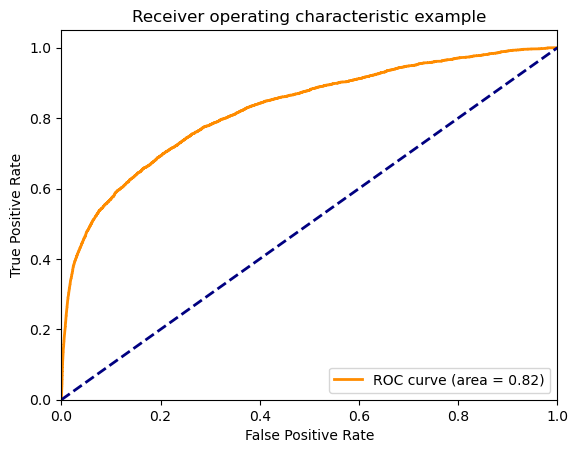

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

n_classes=3
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_1[:], y_score[:])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_1.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 2
plt.plot(
    fpr[2],
    tpr[2],
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc[2],
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic example")
plt.legend(loc="lower right")
plt.show()

In [141]:
fpr, tpr, thresholds = roc_curve(y_test.target,  y_test.prob)
roc_auc = auc(fpr, tpr)
print('Ensemble Area under the ROC curve test : %f' % roc_auc)
print('Ensemble Gini value test : %f' % ((roc_auc*2-1)*100))

Ensemble Area under the ROC curve test : 0.824938
Ensemble Gini value test : 64.987651


In [142]:
to_drop = ['target','codmes']
X_test = df_test.drop(to_drop,axis=1)
y_test = df_test.target

In [143]:
data_test=X_test

In [144]:
data_test['target']=y_test

In [145]:
data_test.rename(columns={0: "target"},inplace=True)

y_test = data_test.target.to_frame()
data_test.drop(['target'],axis=1,inplace=True)

data_test.columns = model.feature_names

predictions = model.predict(xgboost.DMatrix(data_test))

In [146]:
y_test['prob'] = predictions
y_test['decil'] = (pd.qcut(y_test.prob, 10, labels=False)-10)*-1

In [147]:
y_test_1=y_test['target'].values
y_score=y_test['prob'].values

In [148]:
Tabla_Deciles(y_test['target'],y_test['prob'],n=5)

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00251, 0.0113]",36509,154,0.004200,0.203431,1.000000,36509,3848
"(0.0113, 0.017]",36357,306,0.008346,0.406016,0.959979,72866,3694
"(0.017, 0.0237]",36180,482,0.013147,0.607614,0.880457,109046,3388
"(0.0237, 0.0371]",35928,735,0.020047,0.807808,0.755198,144974,2906
"(0.0371, 0.738]",34492,2171,0.059215,1.000000,0.564189,179466,2171


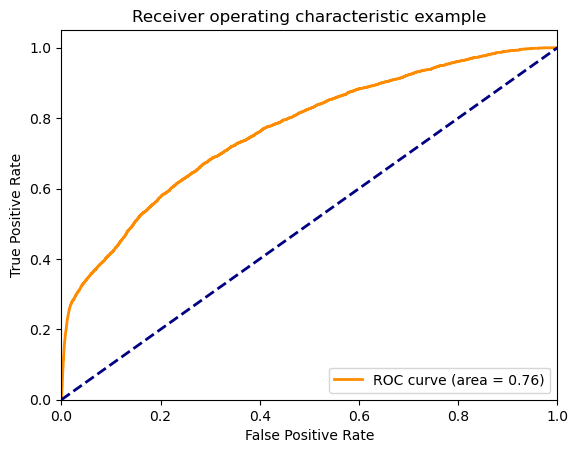

In [149]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

n_classes=3
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_1[:], y_score[:])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_1.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 2
plt.plot(
    fpr[2],
    tpr[2],
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc[2],
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic example")
plt.legend(loc="lower right")
plt.show()

In [150]:
fpr, tpr, thresholds = roc_curve(y_test.target,  y_test.prob)
roc_auc = auc(fpr, tpr)
print('Ensemble Area under the ROC curve test : %f' % roc_auc)
print('Ensemble Gini value test : %f' % ((roc_auc*2-1)*100))

Ensemble Area under the ROC curve test : 0.764291
Ensemble Gini value test : 52.858143


In [75]:
# this takes a minute or two since we are explaining over 30 thousand samples in a model with over a thousand trees
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [76]:
col_names=X_test.columns

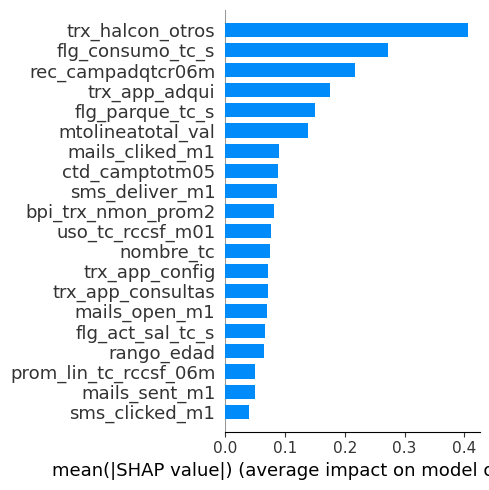

In [77]:
shap.initjs()
shap.summary_plot(shap_values, X_train[col_names], plot_type="bar",plot_size=(5,5))
#shap.summary_plot(shap_values, df[col_names],plot_size=(6,6)).


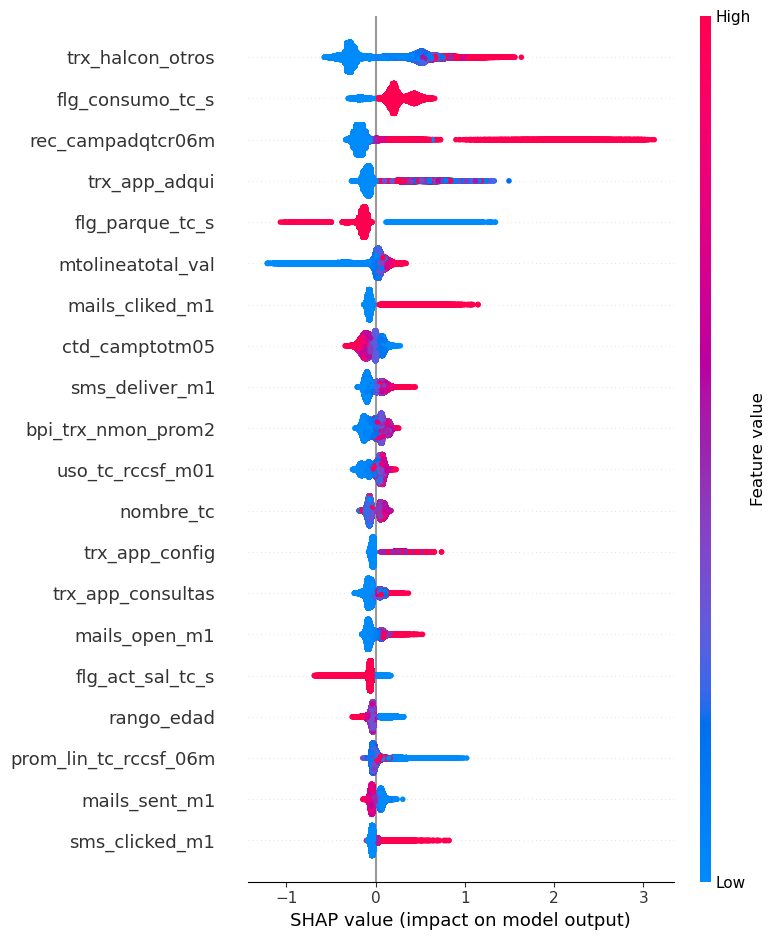

In [78]:
shap.summary_plot(shap_values, X_test)

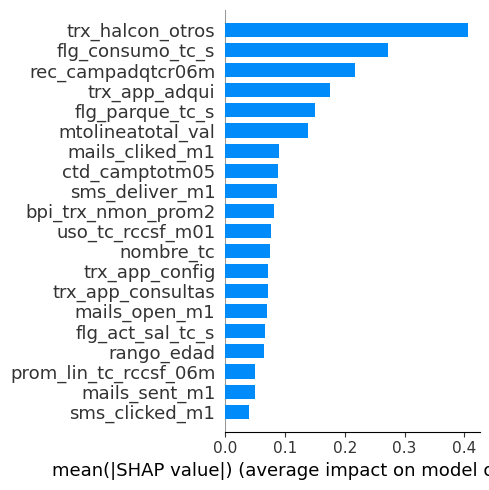

In [79]:
shap.initjs()
shap.summary_plot(shap_values, X[col_names], plot_type="bar",plot_size=(5,5))
#shap.summary_plot(shap_values, df[col_names],plot_size=(6,6))

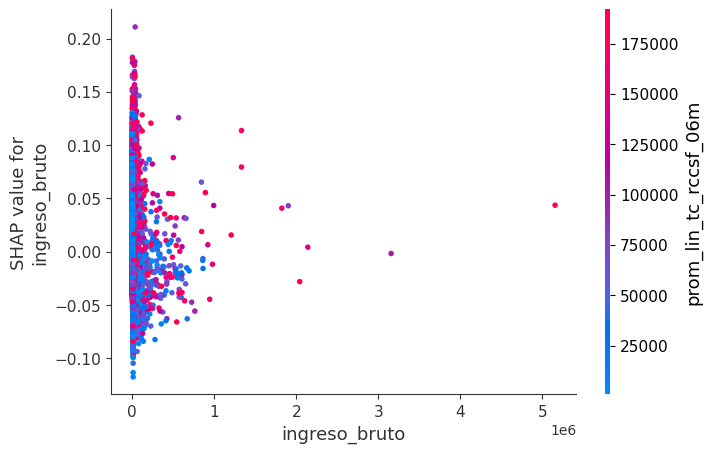

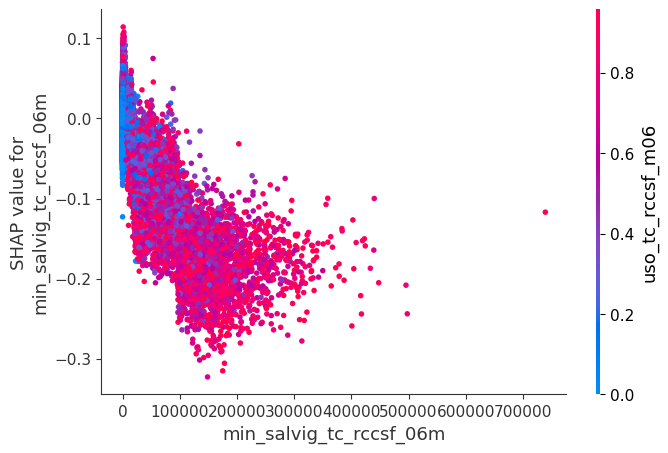

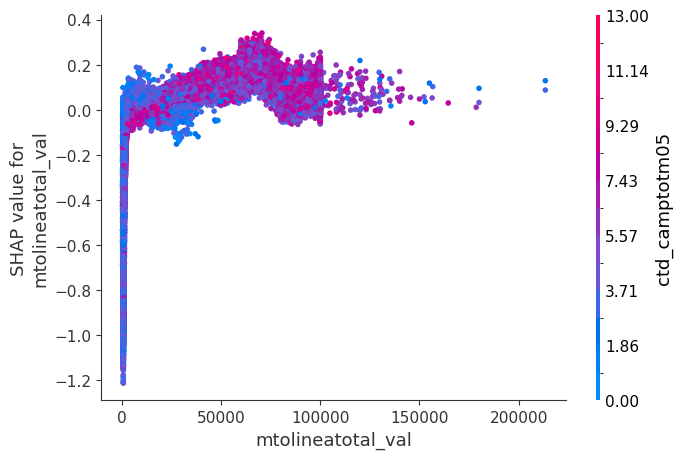

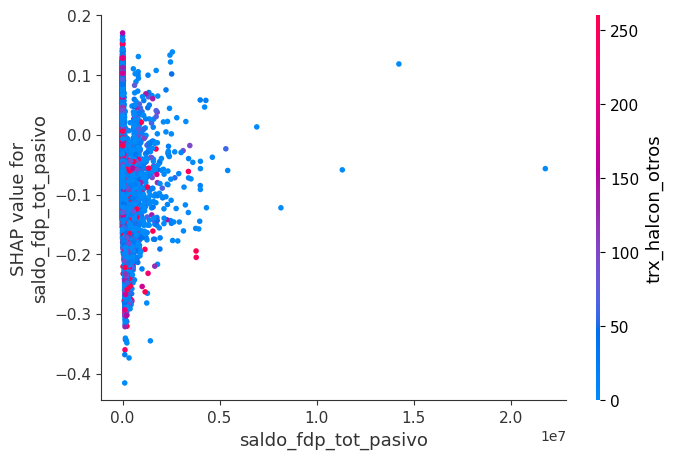

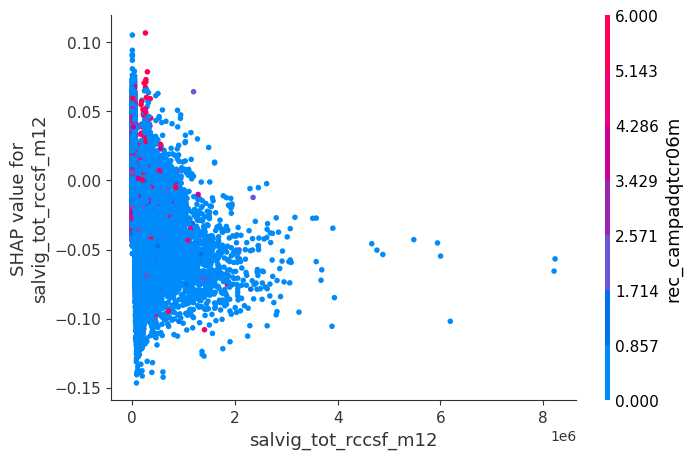

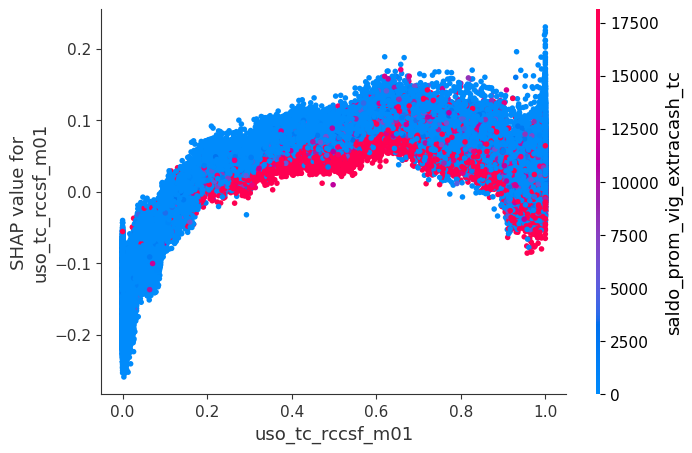

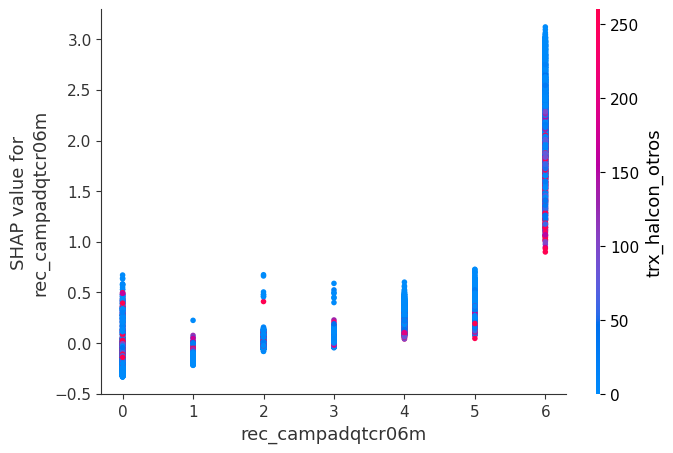

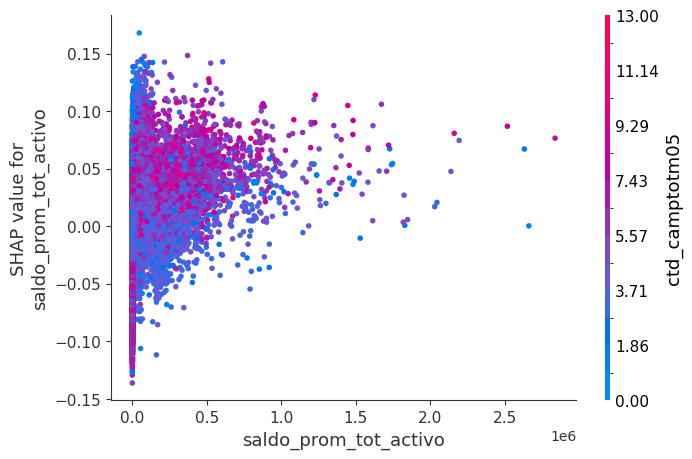

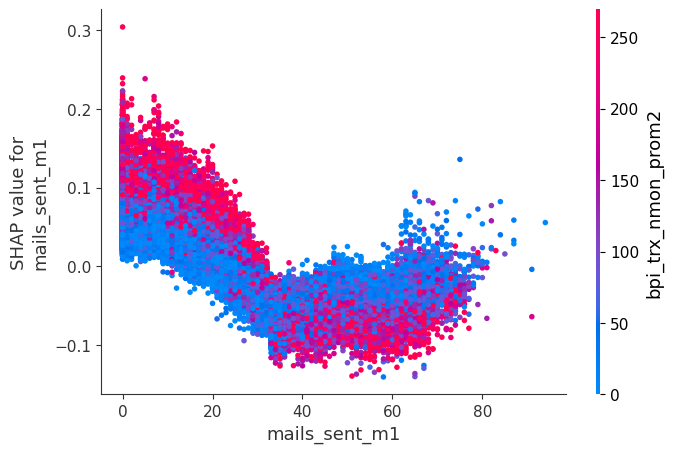

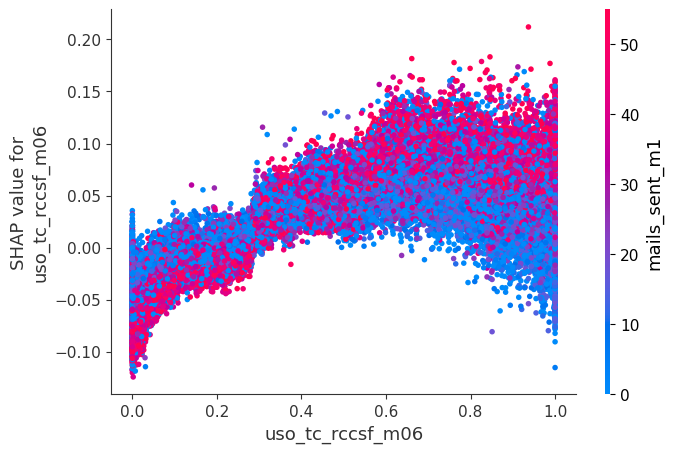

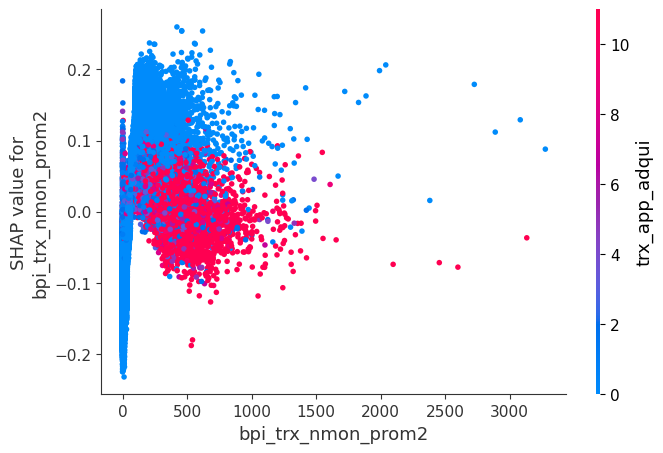

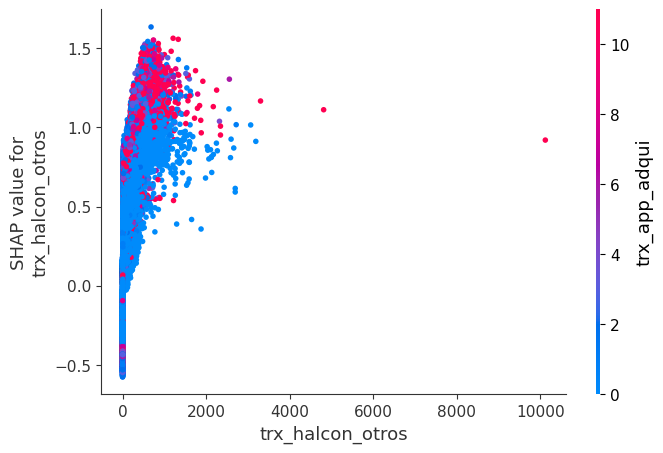

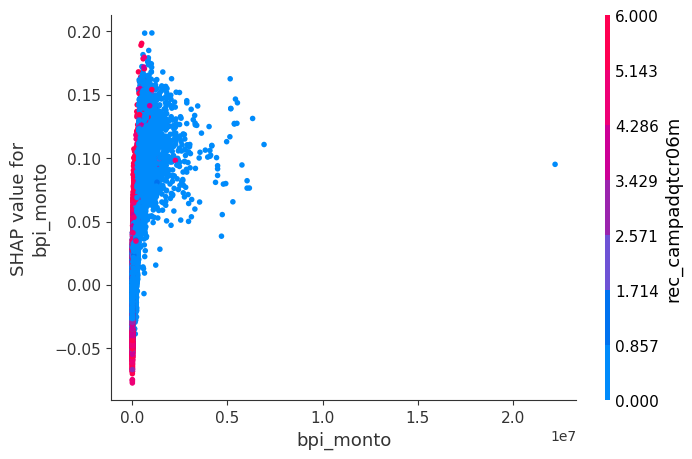

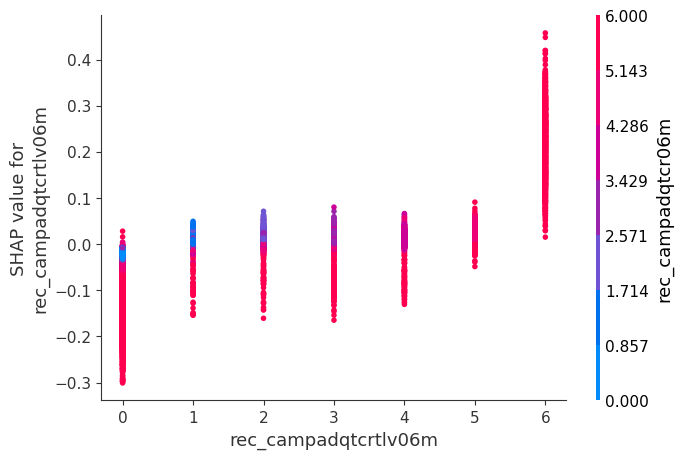

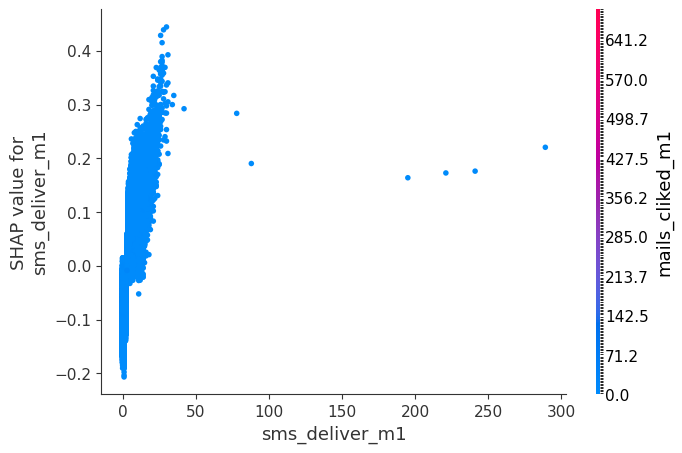

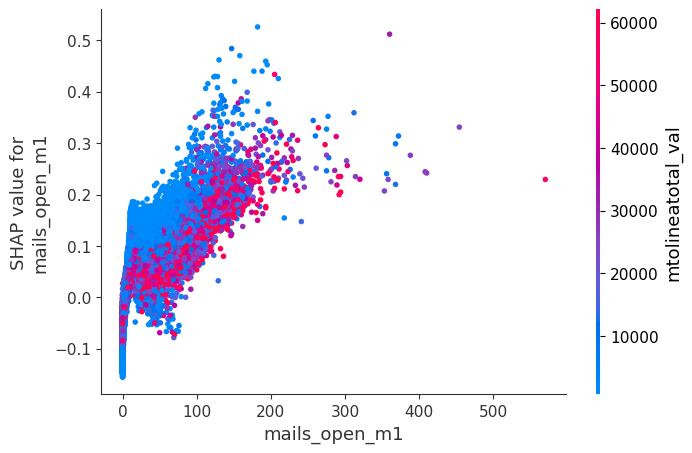

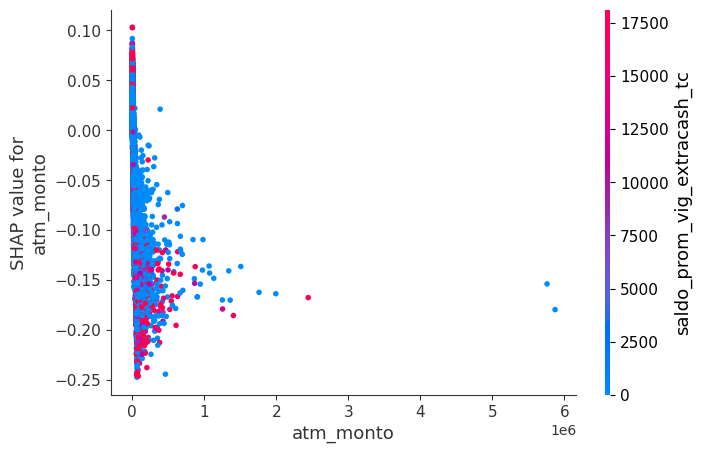

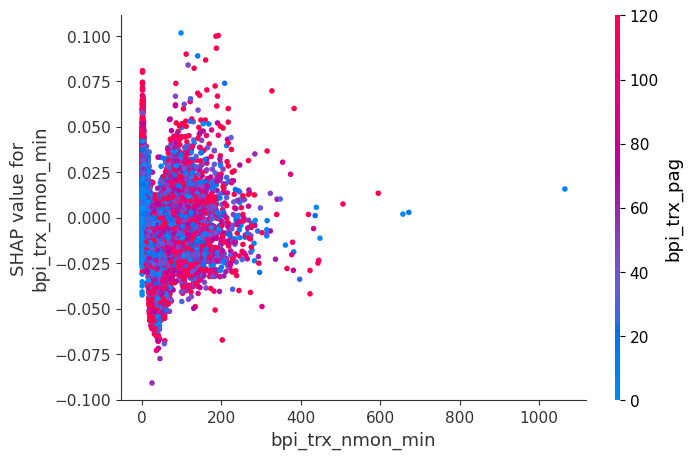

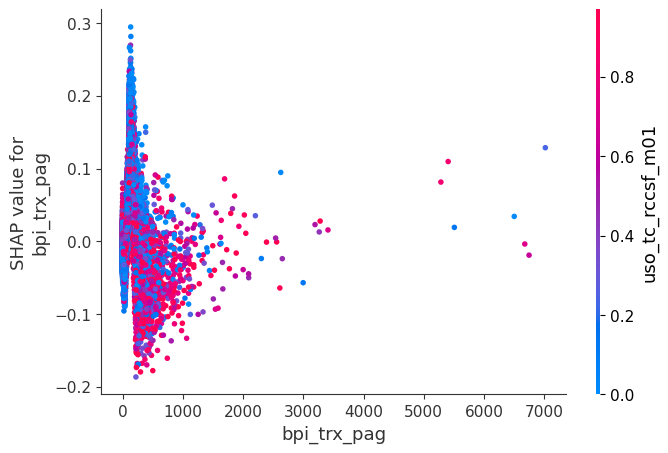

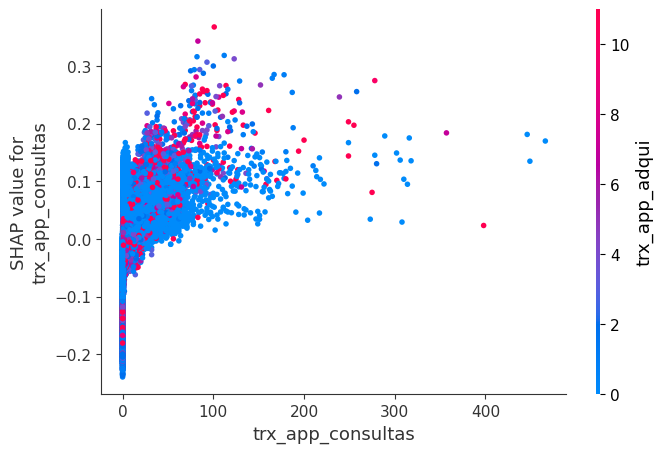

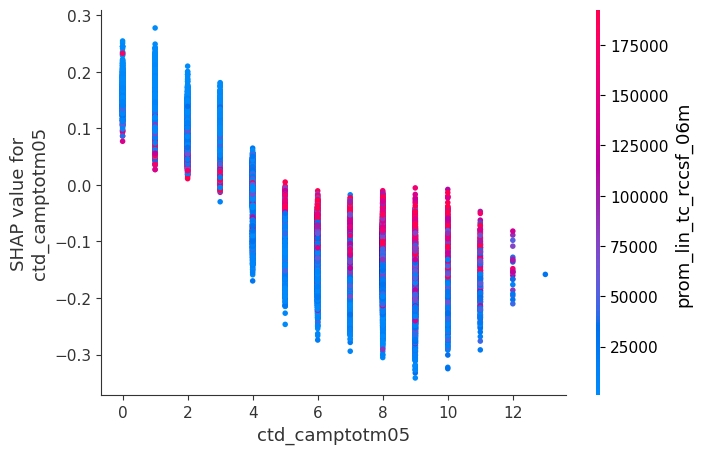

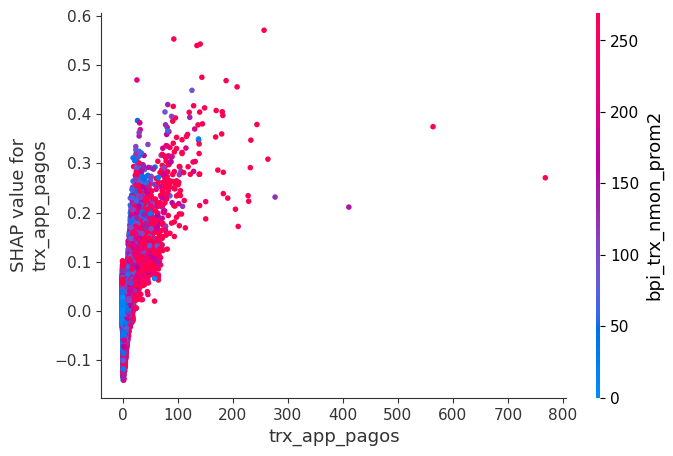

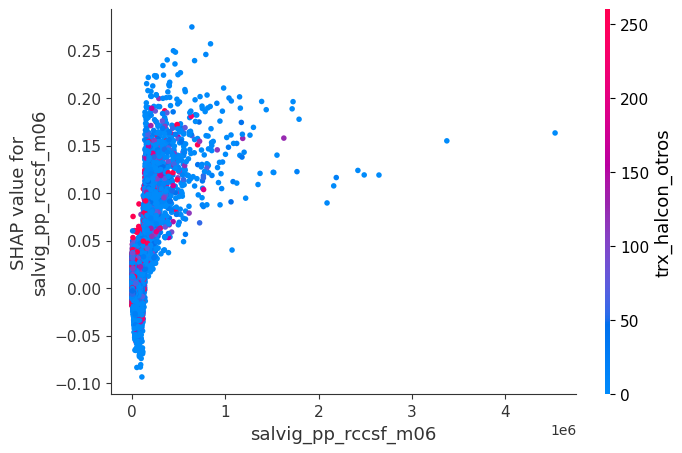

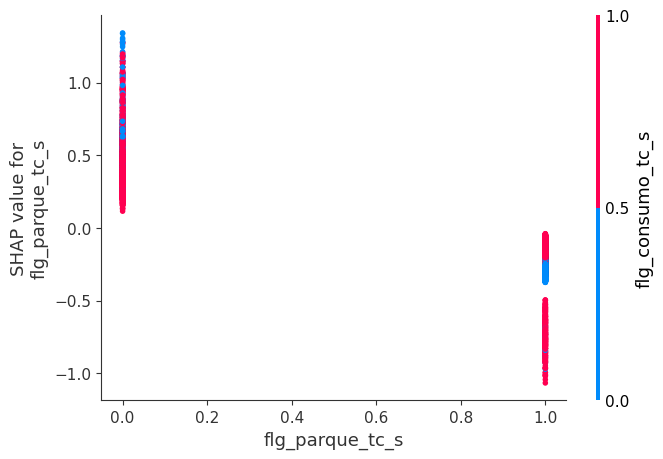

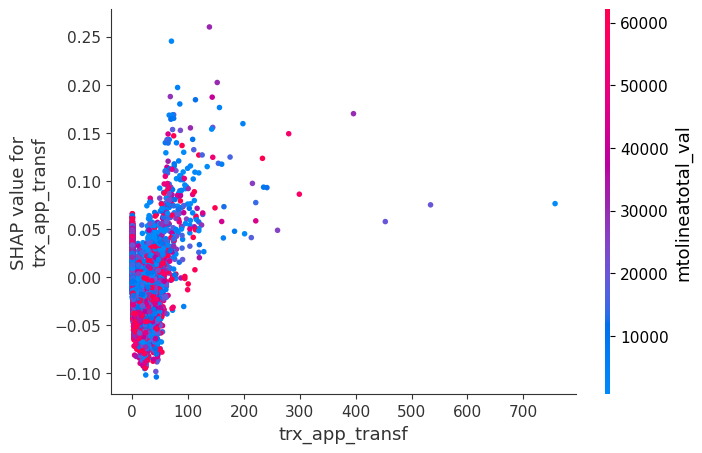

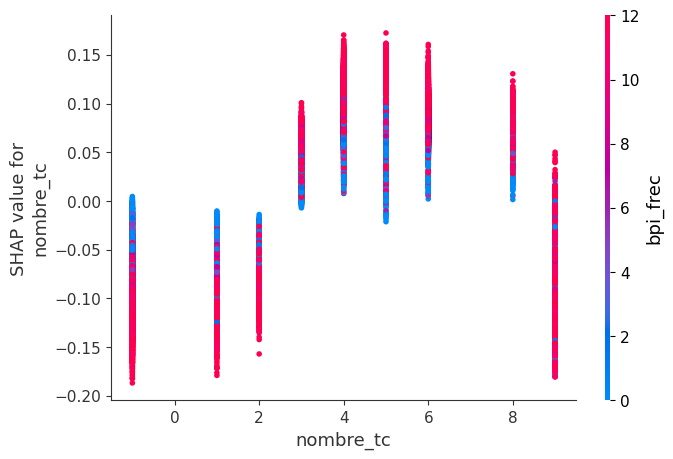

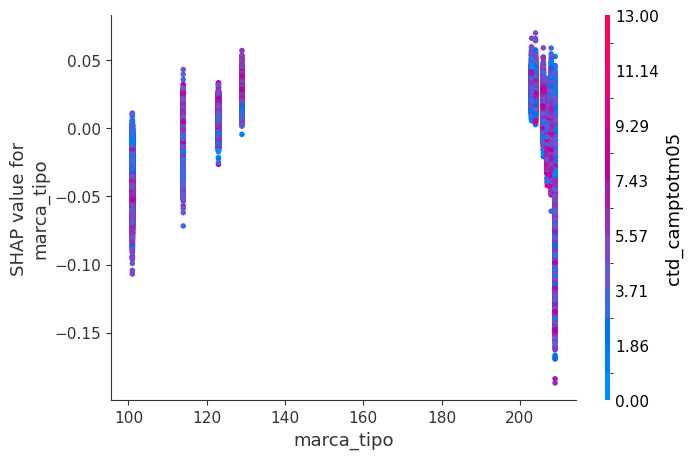

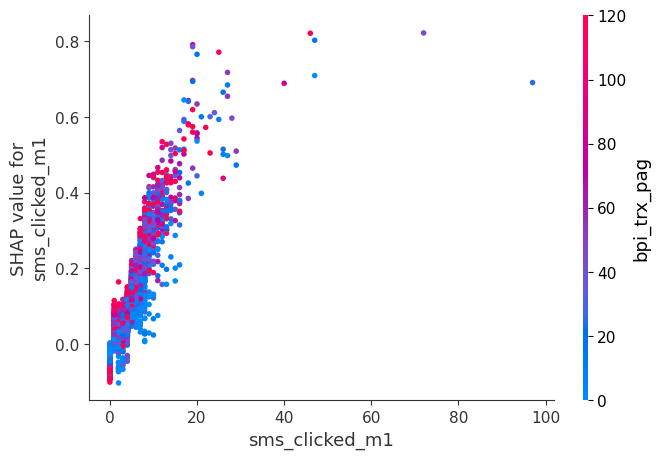

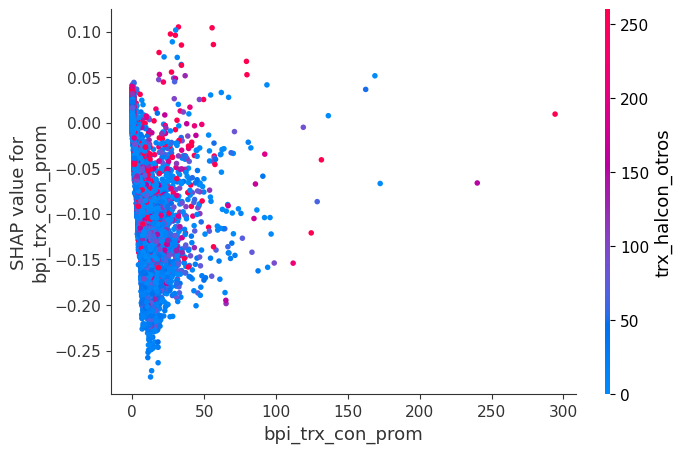

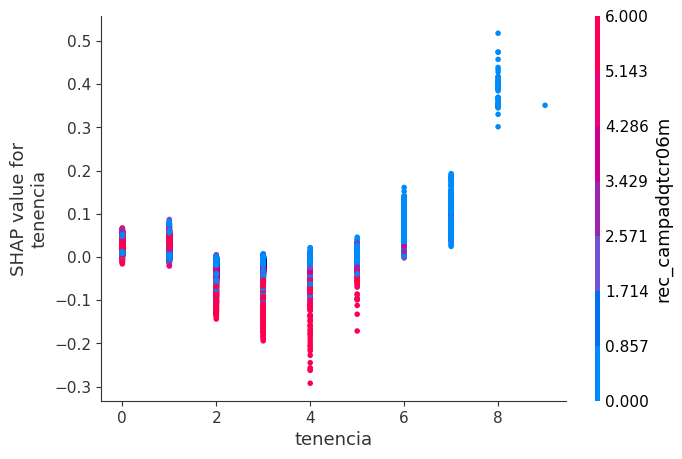

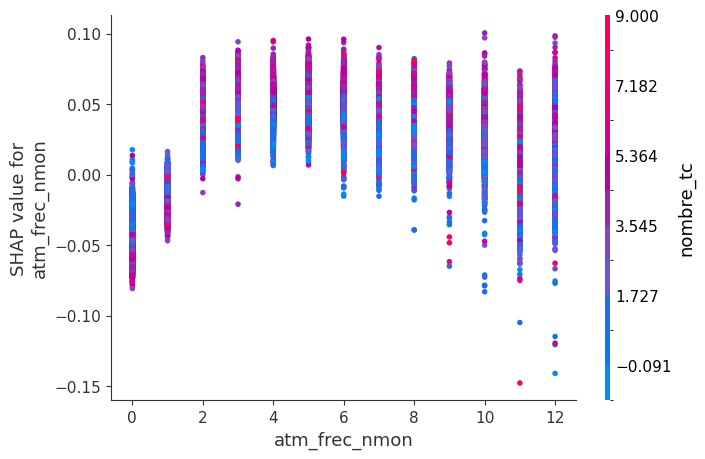

In [151]:
def plot_dependence_multi(features, shap_values, X_test):
    for feature in features:
        shap.dependence_plot(feature,shap_values,X_test)

feature_indices=list(range(1,32))

plot_dependence_multi(feature_indices,shap_values,X_test)

In [152]:
variable_names = X.columns
# Calcula la magnitud promedio de los valores SHAP para cada variable
average_shap_values = np.abs(shap_values).mean(axis=0)

# Crea una lista de tuplas (variable, importancia, valor_absoluto)
variable_importance = [(variable_name, importance, abs_value) for variable_name, importance, abs_value in zip(variable_names, average_shap_values, shap_values.mean(axis=0))]

# Ordena la lista de importancia de mayor a menor
variable_importance.sort(key=lambda x: x[1], reverse=True)

# Obtén las variables más importantes junto con sus importancias y valores absolutos
variables_mas_importantes = [(variable[0], variable[1], variable[2]) for variable in variable_importance]

In [153]:
import csv

# Nombre del archivo CSV de salida
output_csv = 'importancia_variables.csv'

# Escribe los datos en el archivo CSV
with open(output_csv, 'w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    
    # Escribe el encabezado
    csv_writer.writerow(['Variable', 'Importancia', 'Valor Absoluto SHAP'])
    
    # Escribe los datos de cada variable
    for variable in variables_mas_importantes:
        csv_writer.writerow([variable[0], variable[1], variable[2]])

In [154]:
variables_mas_importantes

[('trx_halcon_otros', 0.40561938, 0.106580645),
 ('flg_consumo_tc_s', 0.27296558, 0.26094165),
 ('rec_campadqtcr06m', 0.2170097, -0.0979139),
 ('trx_app_adqui', 0.17506929, 0.024287716),
 ('flg_parque_tc_s', 0.14958279, -0.120813996),
 ('mtolineatotal_val', 0.13900885, -0.04763443),
 ('mails_cliked_m1', 0.09045595, -0.03627779),
 ('ctd_camptotm05', 0.089172736, -0.047645736),
 ('sms_deliver_m1', 0.08657673, -0.019724006),
 ('bpi_trx_nmon_prom2', 0.082156554, -0.0069285166),
 ('uso_tc_rccsf_m01', 0.07621954, -0.010491159),
 ('nombre_tc', 0.075008355, -0.0044571464),
 ('trx_app_config', 0.072214276, 0.0083522),
 ('trx_app_consultas', 0.072084986, -0.042319275),
 ('mails_open_m1', 0.07046452, -0.029445225),
 ('flg_act_sal_tc_s', 0.06635596, -0.06457387),
 ('rango_edad', 0.06524916, -0.012407751),
 ('prom_lin_tc_rccsf_06m', 0.050217558, 0.021477114),
 ('mails_sent_m1', 0.05011867, 0.011844571),
 ('sms_clicked_m1', 0.04040501, -0.02642447),
 ('trx_app_pagos', 0.040373757, -0.018662348),
 ('